# Opis cech zbioru WineQT

Zbiór danych zawiera fizykochemiczne właściwości win oraz ich ocenę jakości. Poniższa tabela przedstawia opis każdej zmiennej wraz z jej znaczeniem.

---

## Opis zmiennych

| Cecha | Opis | Znaczenie praktyczne |
|------|------|---------------------|
| **fixed acidity** | Kwasowość stała (kwasy nieulotne, np. winowy) | Wpływa na świeżość i „ostrość” smaku |
| **volatile acidity** | Kwasowość lotna (głównie kwas octowy) | Wysokie wartości pogarszają zapach i jakość |
| **citric acid** | Kwas cytrynowy | Poprawia świeżość i balans smaku |
| **residual sugar** | Cukier resztkowy po fermentacji | Określa słodycz wina |
| **chlorides** | Zawartość soli (chlorków) | Nadmiar pogarsza smak |
| **free sulfur dioxide** | Wolny SO₂ (aktywny konserwant) | Chroni przed bakteriami i utlenianiem |
| **total sulfur dioxide** | Całkowity SO₂ | Zbyt wysoki → nieprzyjemny zapach |
| **density** | Gęstość cieczy | Związana z cukrem i alkoholem |
| **pH** | Miara kwasowości chemicznej | Wpływa na stabilność i smak |
| **sulphates** | Siarczany | Wspierają konserwację i trwałość |
| **alcohol** | Zawartość alkoholu (%) | Często dodatnio związana z jakością |
| **quality** | Ocena jakości (0–10) | Zmienna docelowa |

---

## Kluczowe zależności

- Wyższa jakość wina często wiąże się z:
  - niższą **volatile acidity**
  - wyższym **alcohol**
  - umiarkowanymi **sulphates**

- Na smak wina wpływają głównie:
  - **acidity (kwasowość)**
  - **sugar (cukier)**
  - **alcohol (alkohol)**


In [1]:
# Read dataset WineQT
import pandas as pd
import numpy as np
pd.set_option('display.max_columns',None)
df = pd.read_csv('Dataset/WineQT.csv')
# Display first 10 rows
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [3]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [4]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [5]:
y = df['quality']
X = df.drop(['quality','Id'],axis=1)

In [16]:
categorial_features = X.select_dtypes(include=['category','str','object']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64','float64']).columns.tolist()

n_samples = len(X)
n_features = len(X.T)
classes, counts = np.unique(y,return_counts=True)
imbalanced_ratio =np.max(counts)/np.min(counts)

print("n_samples: ", n_samples)
print("n_features: ", n_features)
print("categorical: ", categorial_features)
print("numerical: ", numerical_features)
print("classes: ", classes)
print("class samples: ", counts)
print("imbalanced ratio: ", imbalanced_ratio)

n_samples:  1143
n_features:  11
categorical:  []
numerical:  ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
classes:  [3 4 5 6 7 8]
class samples:  [  6  33 483 462 143  16]
imbalanced ratio:  80.5


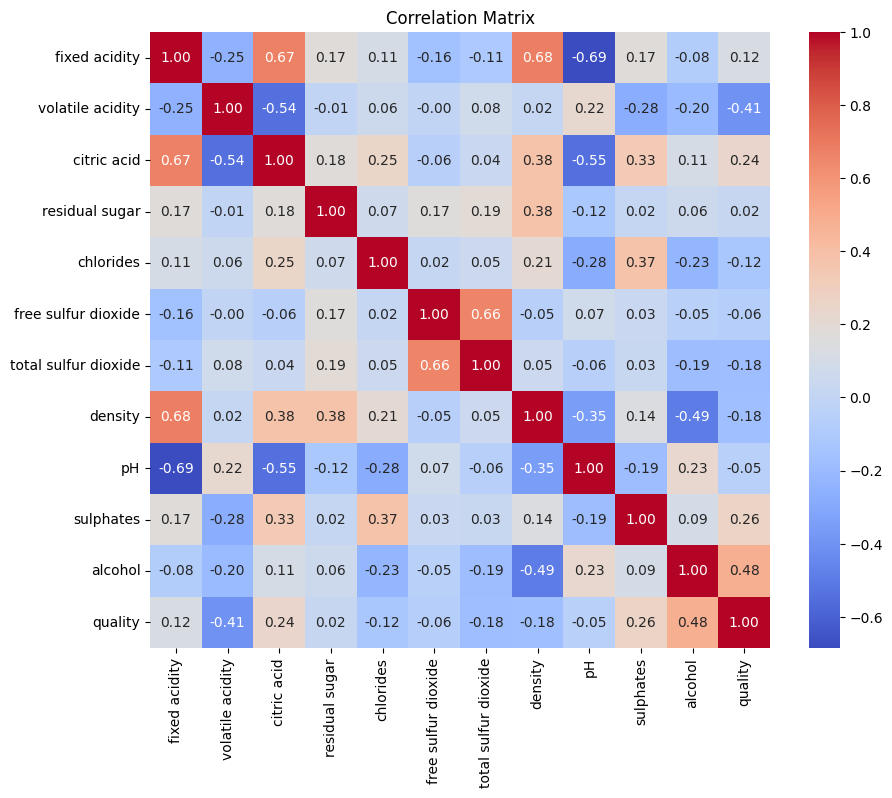

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
df = df.drop(['Id'],axis=1)

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

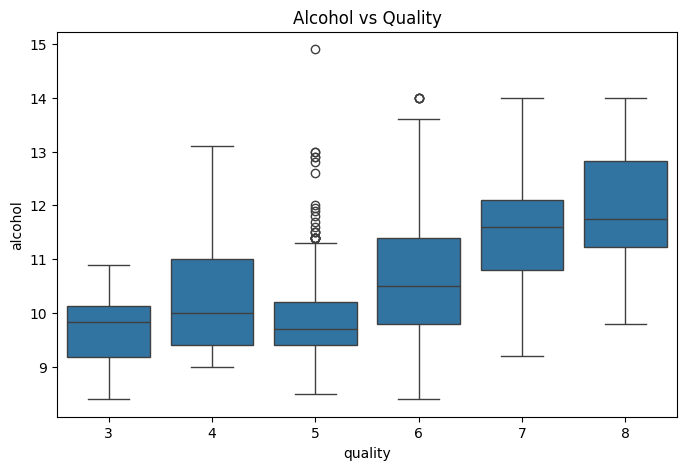

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Alcohol vs Quality')
plt.show()

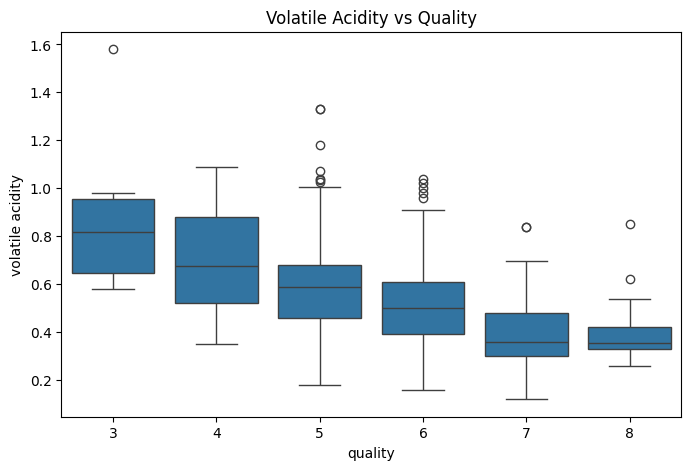

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='quality', y='volatile acidity', data=df)
plt.title('Volatile Acidity vs Quality')
plt.show()

<Axes: xlabel='alcohol', ylabel='volatile acidity'>

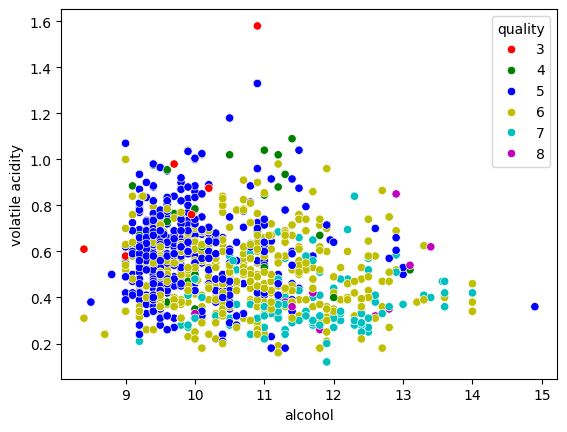

In [35]:
sns.scatterplot(x='alcohol', y='volatile acidity', hue='quality', data=df, palette=['r','g','b','y','c','m'])

<Axes: xlabel='alcohol', ylabel='sulphates'>

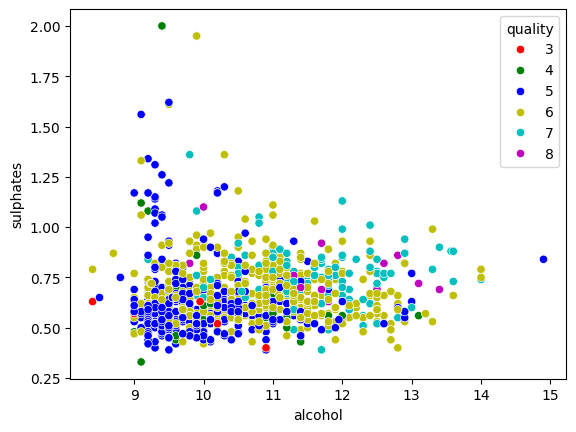

In [36]:
sns.scatterplot(x='alcohol', y='sulphates', hue='quality', data=df, palette=['r','g','b','y','c', 'm'])

<Axes: xlabel='pH', ylabel='Count'>

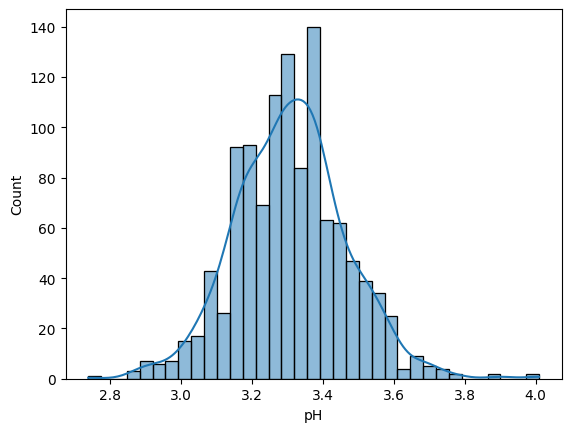

In [23]:
sns.histplot(data=X,x='pH', kde=True)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_arr = scaler.fit_transform(X)
new_X = pd.DataFrame(scaled_arr, columns=X.columns)
new_X.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
5,-0.521580,0.716559,-1.365027,-0.540205,-0.252560,-0.255269,-0.180503,0.555854,1.270695,-0.573658,-0.963382
6,-0.235347,0.382399,-1.059838,-0.687771,-0.379553,-0.060071,0.399334,-0.171711,-0.070340,-1.160774,-0.963382
7,-0.578826,0.660865,-1.365027,-0.982903,-0.464216,-0.060071,-0.760341,-1.107153,0.504389,-1.102062,-0.408711
8,-0.292593,0.271012,-1.263297,-0.392638,-0.294891,-0.645665,-0.851895,0.036165,0.312813,-0.514946,-0.870937
9,-0.922305,0.271012,-0.958109,-0.540205,0.213081,-0.060071,0.582441,-0.431556,-0.198057,-0.691081,-1.148272


In [9]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X)
pca_df = pd.DataFrame(data=pca_data, columns=['PC1','PC2'])
pca_df.shape

(1143, 2)

In [10]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0)
clasters = kmeans.fit_predict(pca_df)
analysis_df = pca_df.copy()
analysis_df['cluster'] = clasters
analysis_df.groupby('cluster').size()

cluster
0    163
1    580
2    400
dtype: int64

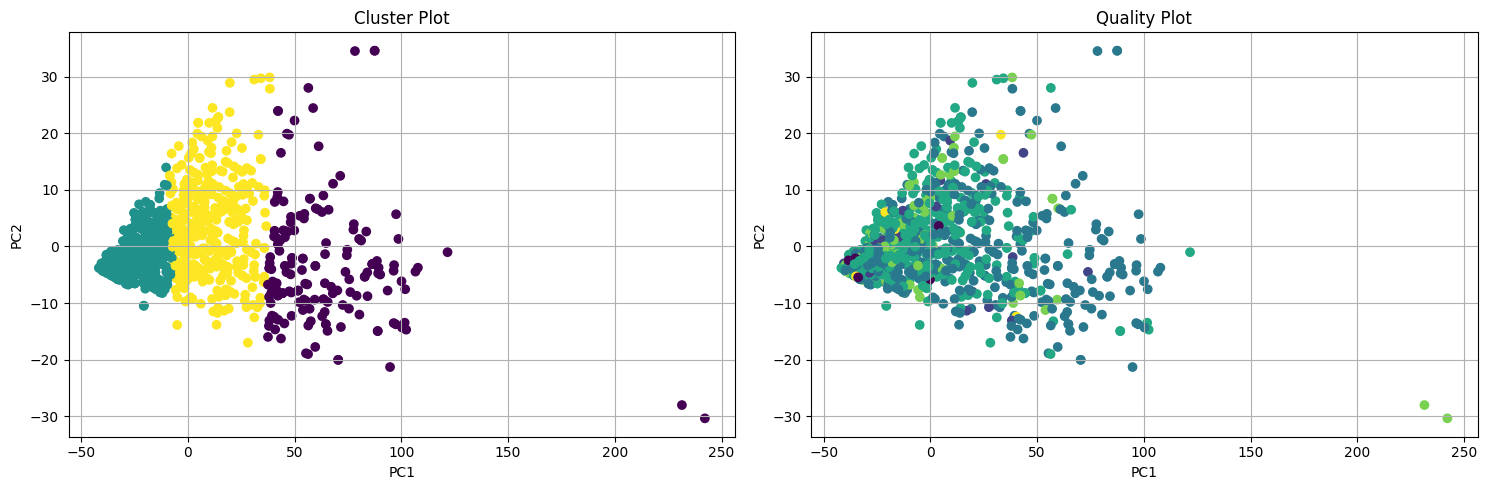

In [11]:
plt.style.use('default')
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.scatter(analysis_df['PC1'],analysis_df['PC2'],c=analysis_df['cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Cluster Plot')
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(analysis_df['PC1'],analysis_df['PC2'],c=y)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Quality Plot')
plt.grid(True)

plt.tight_layout()
plt.show()